In [169]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import load_diabetes

In [170]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

Датасет предсказания прогрессирования болезни

- **age**: Возраст (в годах)
- **sex**: Пол
- **bmi**: Индекс массы тела (Body Mass Index)
- **bp**: Среднее артериальное давление (Blood Pressure)
- **s1 (tc)**: Общий холестерин (Total Serum Cholesterol)
- **s2 (ldl)**: Липопротеины низкой плотности («плохой» холестерин)
- **s3 (hdl)**: Липопротеины высокой плотности («хороший» холестерин)
- **s4 (tch)**: Отношение общего холестерина к ЛВП
- **s5 (ltg)**: Логарифм уровня триглицеридов в сыворотке крови
- **s6 (glu)**: Уровень сахара в крови
- **target**: количественный показатель прогрессирования заболевания через год

In [171]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [172]:
features = diabetes.feature_names
X = df[features].values
n, k = X.shape
y = diabetes.target

In [173]:
# добавим слева столбец единиц для свободного коэффициента
X_with_intercept = np.column_stack((np.ones(n), X))

Реализация линейной регресси

In [174]:
# Формула Метода наименьших квадратов
# beta = (X^T * X)^(-1) * X^T * y

XTX_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)
beta = XTX_inv @ X_with_intercept.T @ y

In [175]:
y_pred = X_with_intercept @ beta
diff = y - y_pred

Оценка

In [176]:
# коэффициенты
intercept_est = beta[0]
coeffs_est = beta[1:]

(np.float64(152.13348416289597),
 array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
        -792.17563855,  476.73902101,  101.04326794,  177.06323767,
         751.27369956,   67.62669218]))

In [177]:
# остаточная дисперсии (несмещенная)
rss = np.sum(diff**2)
sigma_sq_est = rss / (n - k - 1)
rmse = np.sqrt(sigma_sq_est)

54.15423932805569


In [178]:
# R^2
tss = np.sum((y - np.mean(y))**2)
r_squared = 1 - (rss / tss)

0.5177484222203498


In [196]:
# Log-Likelihood
# Для нормальной регрессии логарифмическая функция правдоподобия:
log_likelihood = -n/2 * (np.log(2 * np.pi * rss/n) + 1)

In [198]:
print("--- Результаты модели (Оценки параметров) ---")
print(f"Свободный коэффициент (Intercept): {beta[0]:.4f}")
for name, val in zip(features, beta[1:]):
    print(f"Коэффициент {name}: {val:.4f}")
print(f"\nОценка остаточной дисперсии (sigma^2): {sigma_sq_est:.4f}")
print(f"Коэффициент детерминации R^2: {r_squared:.4f}")
print(f"Log-Likelihood: {log_likelihood:.4f}")

--- Результаты модели (Оценки параметров) ---
Свободный коэффициент (Intercept): 152.1335
Коэффициент age: -10.0099
Коэффициент sex: -239.8156
Коэффициент bmi: 519.8459
Коэффициент bp: 324.3846
Коэффициент s1: -792.1756
Коэффициент s2: 476.7390
Коэффициент s3: 101.0433
Коэффициент s4: 177.0632
Коэффициент s5: 751.2737
Коэффициент s6: 67.6267

Оценка остаточной дисперсии (sigma^2): 2932.6816
Коэффициент детерминации R^2: 0.5177
Log-Likelihood: -2385.9929


## Доверительные интервалы

In [199]:
# Если ошибки распределены нормально, то оценки beta распределены по Стьюденту
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_res)

In [201]:
# Стандартные ошибки коэффициентов
# SE = sqrt(sigma^2 * diag(XTX^-1))
se_beta = np.sqrt(np.diag(sigma_sq_est * XTX_inv))

ci_beta = []
for i in range(len(beta)):
    low = beta[i] - t_crit * se_beta[i]
    high = beta[i] + t_crit * se_beta[i]
    ci_beta.append((low, high))

In [202]:
# ДИ для остаточной дисперсии (используется распределение Хи-квадрат)
chi2_low = stats.chi2.ppf(alpha/2, df_res)
chi2_high = stats.chi2.ppf(1 - alpha/2, df_res)
ci_sigma_sq = (rss / chi2_high, rss / chi2_low)

In [203]:
print("\n--- 0.95 Доверительные интервалы ---")
names = ['Intercept'] + features
for name, ci in zip(names, ci_beta):
    print(f"ДИ для {name}: [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"ДИ для sigma^2: [{ci_sigma_sq[0]:.4f}, {ci_sigma_sq[1]:.4f}]")


--- 0.95 Доверительные интервалы ---
ДИ для Intercept: [147.0707, 157.1963]
ДИ для age: [-127.4460, 107.4263]
ДИ для sex: [-360.1471, -119.4841]
ДИ для bmi: [389.0755, 650.6163]
ДИ для bp: [195.7988, 452.9705]
ДИ для s1: [-1611.1530, 26.8017]
ДИ для s2: [-189.6198, 1143.0978]
ДИ для s3: [-316.6838, 518.7703]
ДИ для s4: [-140.3147, 494.4412]
ДИ для s5: [413.4072, 1089.1402]
ДИ для s6: [-62.0643, 197.3177]
ДИ для sigma^2: [2577.3826, 3367.2807]


## Проверка статистической значимости

In [204]:
# t-статистики для проверки гипотез H0: beta_i = 0
t_stats = beta / se_beta
p_values_t = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_res))

In [205]:
# F-статистика для модели в целом
# H0: Все коэффициенты при признаках равны нулю
f_stat = ((tss - rss) / k) / (rss / df_res)
p_value_f = 1 - stats.f.cdf(f_stat, k, df_res)

In [206]:
print("\n--- Проверка значимости ---")
for name, t, p in zip(names, t_stats, p_values_t):
    print(f"Переменная {name}: t-stat = {t:.4f}, p-value = {p:.4e}")
print(f"Модель в целом (F-test/ANOVA): F-stat = {f_stat:.4f}, p-value = {p_value_f:.4e}")


--- Проверка значимости ---
Переменная Intercept: t-stat = 59.0614, p-value = 0.0000e+00
Переменная age: t-stat = -0.1675, p-value = 8.6703e-01
Переменная sex: t-stat = -3.9171, p-value = 1.0417e-04
Переменная bmi: t-stat = 7.8133, p-value = 4.2855e-14
Переменная bp: t-stat = 4.9583, p-value = 1.0243e-06
Переменная s1: t-stat = -1.9012, p-value = 5.7948e-02
Переменная s2: t-stat = 1.4062, p-value = 1.6039e-01
Переменная s3: t-stat = 0.4754, p-value = 6.3472e-01
Переменная s4: t-stat = 1.0965, p-value = 2.7346e-01
Переменная s5: t-stat = 4.3704, p-value = 1.5559e-05
Переменная s6: t-stat = 1.0249, p-value = 3.0599e-01
Модель в целом (F-test/ANOVA): F-stat = 46.2724, p-value = 0.0000e+00


**ВЫВОД**:
* Модель в целом статистически значима (F-test p < 0.001)
* Индивидуально значимые предикторы (p < 0.05): sex, bmi, bp, s5
* Предиктор s1 (холестерин) находится на границе значимости (p=0.058)
* Незначимость большинства показателей крови (s1-s4, s6) при общей адекватности модели говорит о наличии сильной мультиколлинеарности

## Проверка посылок теоремы Гаусса-Маркова и нормальности

Теорема Гаусса-Маркова утверждает, что МНК-оценки являются BLUE при выполнении условий:
1. Линейность
2. Полнота ранга X
3. Экзогенность (E[e|X]=0)
4. Гомоскедастичность
5. Отсутствие автокорреляции

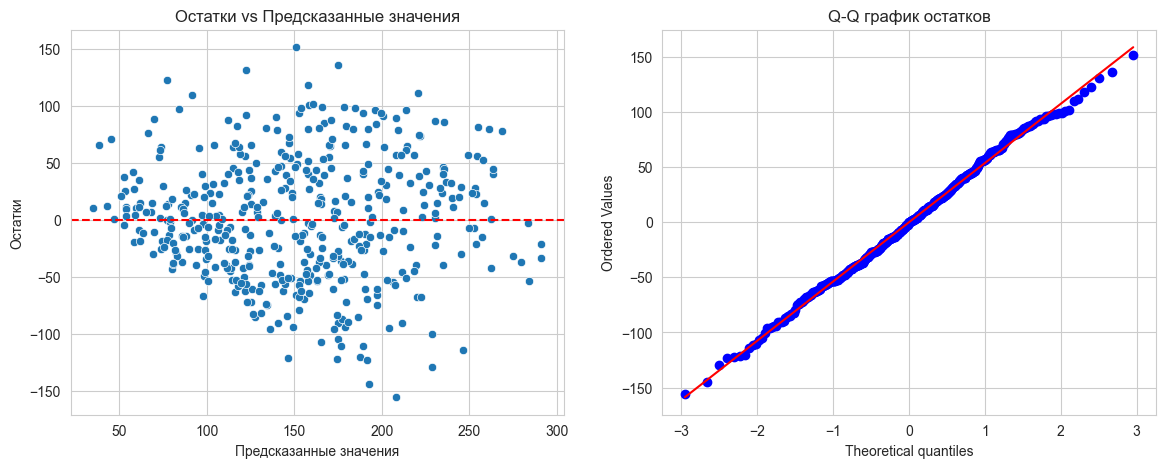

In [210]:
plt.figure(figsize=(14, 5))
# График остатков (Гомоскедастичность и Линейность)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=diff)
plt.axhline(0, color='red', linestyle='--')
plt.title("Остатки vs Предсказанные значения")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")

# Q-Q график (Нормальность остатков - Тема 5)
plt.subplot(1, 2, 2)
stats.probplot(diff, dist="norm", plot=plt)
plt.title("Q-Q график остатков")
plt.show()

In [212]:
# Тесты
_, p_norm = stats.shapiro(diff)
dw_stat = np.sum(np.diff(diff)**2) / np.sum(diff**2)

print(f"Среднее значение остатков (E[e]): {np.mean(diff):.2e}")
print(f"Тест на нормальность Shapiro-Wilk (p-value): {p_norm:.4f}")
print(f"Статистика Дарбина-Уотсона: {dw_stat:.4f}")

Среднее значение остатков (E[e]): -1.26e-14
Тест на нормальность Shapiro-Wilk (p-value): 0.6162
Статистика Дарбина-Уотсона: 2.0285


1. Математическое ожидание ошибок E[e] ≈ 0 (-1.26e-14)
2. Тест Shapiro-Wilk (p=0.616) -> остатки распределены нормально. Следовательно,
   основная теорема нормальной регрессии применима (t и F тесты математически верны)
3. Статистика Дарбина-Уотсона (2.029) - значение близко к 2, автокорреляция отсутствует
4. Гомоскедастичность: график остатков подтверждает постоянство дисперсии ошибок

**ВЫВОД**: все условия теоремы Гаусса-Маркова выполнены, МНК-оценки являются BLUE

## Мультиколлинеарность

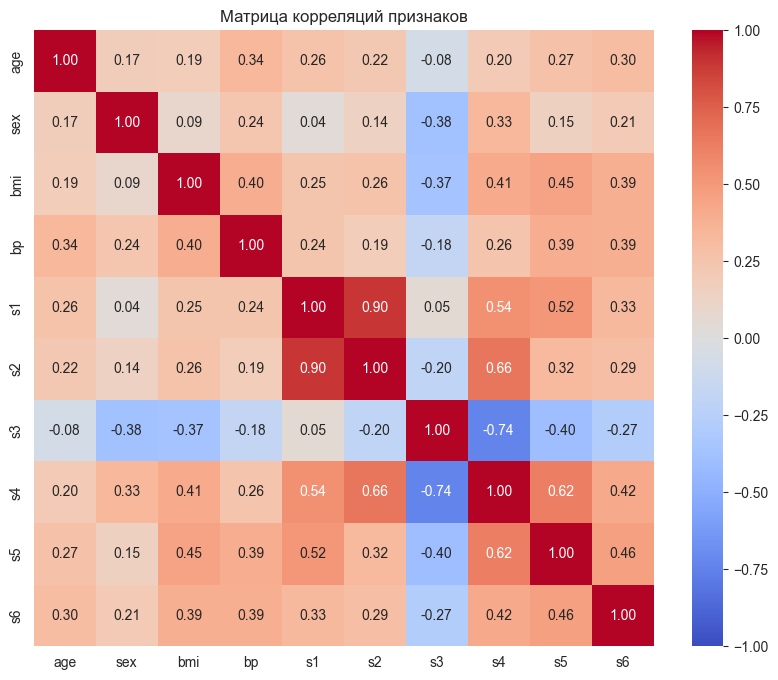

In [213]:
corr_matrix = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Матрица корреляций признаков")
plt.show()

Выявлена сильная корреляция между s1 и s2 = 0.9


Это нарушает условие об отсутствии мультиколлинеарности, что увеличивает стандартные ошибки и делает оценки параметров крови (s1-s4) менее надежными, хотя свойство BLUE сохраняется

## Сравнение со statmodels

In [214]:
print("\n--- Сравнение с эталонной реализацией (statsmodels) ---")
X_sm = sm.add_constant(df[features])
model_sm = sm.OLS(y, X_sm).fit()
print(f"Разница в коэффициентах (max abs): {np.max(np.abs(beta - model_sm.params.values)):.2e}")
print(f"Разница в R^2: {np.abs(r_squared - model_sm.rsquared):.2e}")


--- Сравнение с эталонной реализацией (statsmodels) ---
Разница в коэффициентах (max abs): 4.18e-12
Разница в R^2: 1.11e-16
